In [276]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

NUMBER_OF_SQUARES = 11
NUMBER_OF_GAMES = int(1e3)
START_POS_ALICE = 1
START_POS_BOB = NUMBER_OF_SQUARES - 2

np.set_printoptions(formatter={'float': '{: 0.2f}'.format}, linewidth=100)

In [277]:
# Softmax to perform Boltzmann exploration
def softmax(vector, temperature):
  exp_vector = np.exp(vector / temperature)
  return exp_vector / np.sum(exp_vector)

class Walker():
  def __init__(self, name, start_position, world_dimension, use_brain, learn, learning_rate=0.5, discount_factor=1, softmax_temperature=1):
    self.name = name
    self.start_position = start_position
    self.position = start_position

    self.memory = {
        'my_previous_position': None,
        'my_previous_move': None,
        'other_walker_previous_position': None
    }

    self.world_dimension = world_dimension

    # Initialization as random walker
    self.q_table = np.ones((world_dimension, world_dimension, 3)) / 3

    self.learning_rate = learning_rate
    self.discount_factor = discount_factor

    self.softmax_temperature = softmax_temperature

    self.use_brain = use_brain
    self.learn = learn

  def reset(self):
    self.position = self.start_position
    self.memory = {
        'my_previous_position': None,
        'my_previous_move': None,
        'other_walker_previous_position': None
    }

  def update_memory(self, my_position, other_position, my_move):
    self.memory['my_previous_position'] = my_position
    self.memory['my_previous_move'] = my_move
    self.memory['other_walker_previous_position'] = other_position

  def get_policy_tensor(self):
    probability_tensor = np.zeros((self.world_dimension, self.world_dimension, 3))
    for i in range(self.world_dimension):
      for j in range(self.world_dimension):
        probability_tensor[i, j] = softmax(self.q_table[i, j], self.softmax_temperature)
    return probability_tensor

  def choose_move(self, other_walker_position):
    if self.use_brain:
      # Policy
      probabilities = softmax(self.q_table[self.position, other_walker_position], self.softmax_temperature)
      move = np.random.choice([-1, 0, 1], p=probabilities)
    else:
      move = np.random.choice([-1, 0, 1])
    return move

  def check_if_move_is_possible(self, move):
    # Check if we end up under 0
    if self.position + move < 0:
      return False
    # Check if we end up over the world dimension
    elif self.position + move >= self.world_dimension:
      return False
    else:
      return True

  def move(self, other_position):
    move = self.choose_move(other_position)
    self.update_memory(self.position, other_position, move)
    if self.check_if_move_is_possible(move):
      self.position += move

  def update_brain(self, reward, other_position):
    if self.learn:
      old_q_value = self.q_table[self.memory['my_previous_position'], self.memory['other_walker_previous_position'], self.memory['my_previous_move'] + 1]
      new_q_value = reward + self.discount_factor * np.max(self.q_table[self.position, other_position])
      self.q_table[self.memory['my_previous_position'], self.memory['other_walker_previous_position'], self.memory['my_previous_move'] + 1] = \
        (1-self.learning_rate) * old_q_value + self.learning_rate * new_q_value


In [278]:
def check_same_position(walker_1, walker_2):
  if walker_1.position == walker_2.position:
    return True
  else:
    return False

def check_compenetration(walker_1, walker_2):
  if walker_1.memory['my_previous_position'] == walker_2.position and walker_2.memory['my_previous_position'] == walker_1.position:
    return True
  else:
    return False

def check_end_game(walker_1, walker_2):
  end_game = False
  compenetration = False
  if check_same_position(walker_1, walker_2):
    end_game = True
  elif check_compenetration(walker_1, walker_2):
    # Coin toss to choose the final position of the two walkers
    if np.random.rand() < 0.5:
      walker_1.position = walker_2.position
    else:
      walker_2.position = walker_1.position
    end_game = True
    compenetration = True
  else:
    end_game = False

  return end_game, compenetration


def play_one_game(walker_1, walker_2, world_dimension, calculate_reward, learning=True):
  # Reset the walkers
  walker_1.reset()
  walker_2.reset()
  moves = 0
  while True:
    walker_1.move(walker_2.position)
    walker_2.move(walker_1.position)
    moves += 1

    end_game, compenetration = check_end_game(walker_1, walker_2)

    if end_game:

      if walker_1.position != walker_2.position:
        raise Exception('The walkers are not in the same position at the end of the game')
      else:
        meeting_square = walker_1.position

      walker_1_reward, walker_2_reward = calculate_reward(
          meeting_square,
          world_dimension,
          time = moves
        )
      if learning:
        walker_1.update_brain(walker_1_reward, walker_2.position)
        walker_2.update_brain(walker_2_reward, walker_1.position)
      break
    else:
      if learning:
        walker_1.update_brain(0, walker_2.position)
        walker_2.update_brain(0, walker_1.position)

  return walker_1_reward, walker_2_reward, moves, meeting_square, compenetration

In [279]:
reward_functions = []

# 1.) Linear reward function
def linear_reward(meeting_square, world_dimension, time=None):
  alice_reward = (world_dimension-1)/2 - meeting_square
  bob_reward = -alice_reward
  return alice_reward, bob_reward

reward_functions.append(linear_reward)

# 2.) Time dependent reward function
def time_dependent_reward(meeting_square, world_dimension, time=0):
  alice_reward = (world_dimension-1)/2 - meeting_square - time/(world_dimension**2)
  bob_reward = -alice_reward
  return alice_reward, bob_reward

reward_functions.append(time_dependent_reward)


# 3.) Sinusoidal reward function
def sinusoidal_reward(meeting_square, world_dimension, time=None):
  # Normalize the meeting square to the range [0, 1]
  normalized_square = meeting_square / (world_dimension - 1)
  # Calculate the reward using a sinusoidal function
  alice_reward = np.sin(normalized_square * np.pi)
  bob_reward = -alice_reward
  return alice_reward, bob_reward

reward_functions.append(sinusoidal_reward)

# 4.) Higher frequency sinusoidal reward function
def high_frequency_sinusoidal_reward(meeting_square, world_dimension, time=None):
  # Normalize the meeting square to the range [0, 1]
  normalized_square = meeting_square / (world_dimension - 1)
  # Calculate the reward using a higher frequency sinusoidal function
  alice_reward = np.sin(4 * np.pi * normalized_square)
  bob_reward = -alice_reward
  return alice_reward, bob_reward

reward_functions.append(high_frequency_sinusoidal_reward)

max_rewards = []
for reward_function in reward_functions:
  max = 0
  for i in range(NUMBER_OF_SQUARES):
    alice_reward = reward_function(i, NUMBER_OF_SQUARES)[0]
    if alice_reward > max:
      max = alice_reward
  max_rewards.append(max)

for i, reward_function in enumerate(reward_functions):
  print(f'Reward function {i+1}: {reward_function.__name__} - Max reward: {max_rewards[i]}')


Reward function 1: linear_reward - Max reward: 5.0
Reward function 2: time_dependent_reward - Max reward: 5.0
Reward function 3: sinusoidal_reward - Max reward: 1.0
Reward function 4: high_frequency_sinusoidal_reward - Max reward: 0.9510565162951535


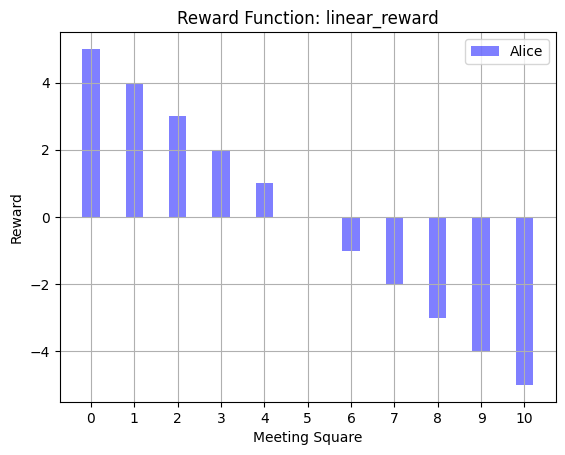

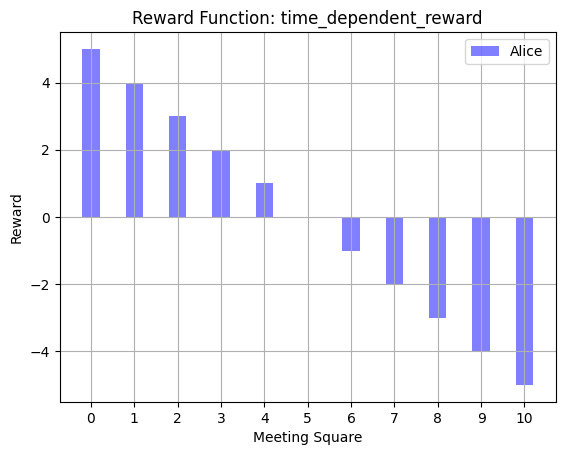

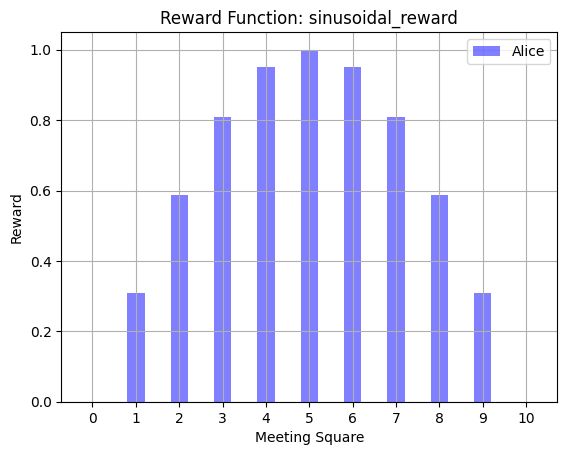

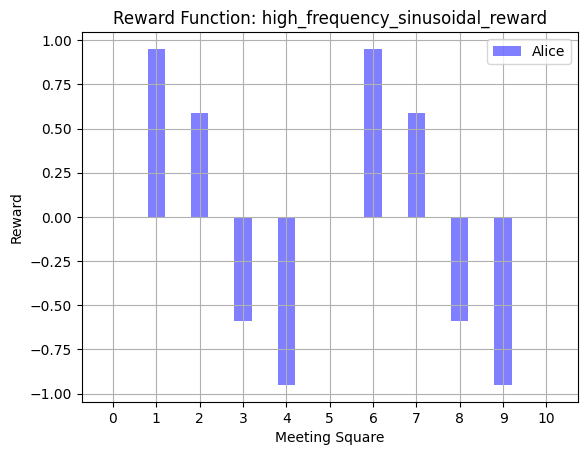

In [280]:
# Plot Reward Function
def plot_reward_function(reward_function, world_dimension):
  x = np.arange(world_dimension)
  y = np.zeros(world_dimension)
  for i in range(world_dimension):
    y[i] = reward_function(i, world_dimension)[0]
  
  plt.bar(x, y, label='Alice', alpha=0.5, color='blue', width=0.4, align='center')
  plt.xticks(x)
  plt.xlabel('Meeting Square')
  plt.ylabel('Reward')
  plt.title(f'Reward Function: {reward_function.__name__}')
  plt.legend()
  plt.grid()
  plt.show()

for reward_function in reward_functions:
  plot_reward_function(reward_function, NUMBER_OF_SQUARES)

In [281]:
# Build matrix A

def convert_indices_to_global(i, j, i_prime, j_prime):
    '''
    This is crucial!
    (i, j) position and future position of the first walker
    (i_prime, j_prime) position and future position of the second walker
    The priming indicates the second walker!
    ATTENTION: the global indices work only if swapped for some reason!
    '''
    global_i = i * NUMBER_OF_SQUARES + i_prime
    global_j = j * NUMBER_OF_SQUARES + j_prime
    return global_i, global_j

def impose_reflective_boundary_conditions(probability_tensor):
  '''
  Transfers the probability mass from the sides to the stationary state.
  This is crucial since in the simulation the walkers are not allowed to go outside the world.
  And this limit is enforced by the environment!
  '''
  for i in range(NUMBER_OF_SQUARES):
    probability_tensor[0, i, 1] += probability_tensor[0, i, 0]
    probability_tensor[0, i, 0] = 0
    probability_tensor[NUMBER_OF_SQUARES-1, i, 1] += probability_tensor[NUMBER_OF_SQUARES-1, i, 2]
    probability_tensor[NUMBER_OF_SQUARES-1, i, 2] = 0

def build_matrix_A(walker_1_prob_tensor, walker_2_prob_tensor):
  '''
  Be careful! j (j') is the starting position!
  '''

  A = np.zeros((NUMBER_OF_SQUARES**2, NUMBER_OF_SQUARES**2))

  for i in range(NUMBER_OF_SQUARES):
    for j in range(NUMBER_OF_SQUARES):
      for i_prime in range(NUMBER_OF_SQUARES):
        for j_prime in range(NUMBER_OF_SQUARES):
          
          global_i, global_j = convert_indices_to_global(i, j, i_prime, j_prime)

          if np.abs(j-i) > 1 or np.abs(j_prime-i_prime) > 1:
            A[global_i, global_j] = 0

          elif j == i + 1 and j_prime == i_prime +1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 0] * walker_2_prob_tensor[j_prime, j, 0]

          elif j == i + 1 and j_prime == i_prime:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 0] * walker_2_prob_tensor[j_prime, j, 1]

          elif j == i + 1 and j_prime == i_prime - 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 0] * walker_2_prob_tensor[j_prime, j, 2]

          elif j == i and j_prime == i_prime + 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 1] * walker_2_prob_tensor[j_prime, j, 0]

          elif j == i and j_prime == i_prime:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 1] * walker_2_prob_tensor[j_prime, j, 1]

          elif j == i and j_prime == i_prime -1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 1] * walker_2_prob_tensor[j_prime, j, 2]

          elif j == i - 1 and j_prime == i_prime + 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 2] * walker_2_prob_tensor[j_prime, j, 0]

          elif j == i - 1 and j_prime == i_prime:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 2] * walker_2_prob_tensor[j_prime, j, 1]

          elif j == i - 1 and j_prime == i_prime - 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 2] * walker_2_prob_tensor[j_prime, j, 2]
            
          else:
            raise Exception('This should not happen')

  return A

def add_absorbent_interactions(A, number_of_sites):
  # Insert interactions by replacing the columns with index: i + (i-1)*number_of_sites -1
  # with the identity column
  # (Notice the -1, it is there because the index start from 0 and not from 1)

  trap_indices_list = [i + (i-1)*number_of_sites - 1 for i in range(1, number_of_sites+1)]

  for index in trap_indices_list:
    A[:, index] = np.eye(number_of_sites**2)[:, index]

def remove_forbidden_compenetraion_processes(A):
  A_non_comp = np.copy(A)
  number_of_sites = np.sqrt(A.shape[0]).astype(int)

  # Finding indexes of forbidden processes

  indices_i_switch_processes = []
  indices_j_switch_processes = []

  for k in range(1, number_of_sites):
    current_i = k+1+(k-1)*number_of_sites
    current_j = k+k*number_of_sites
    indices_i_switch_processes.append(current_i)
    indices_j_switch_processes.append(current_j)

  for k in range(2, number_of_sites+1):
    current_i = k-1+(k-1)*number_of_sites
    current_j = k+(k-2)*number_of_sites
    indices_i_switch_processes.append(current_i)
    indices_j_switch_processes.append(current_j)

  current_i = 1+(number_of_sites-1)*number_of_sites
  current_j = number_of_sites
  indices_i_switch_processes.append(current_i)
  indices_j_switch_processes.append(current_j)

  current_i = number_of_sites
  current_j = 1+(number_of_sites-1)*number_of_sites
  indices_i_switch_processes.append(current_i)
  indices_j_switch_processes.append(current_j)

  number_of_transfers_needed = len(indices_i_switch_processes)

  # -1 slide to conform to cs indices

  for i in range(number_of_transfers_needed):
    indices_i_switch_processes[i] -= 1
    indices_j_switch_processes[i] -= 1

  indices_i_still_processes = indices_j_switch_processes.copy()
  indices_j_still_processes = indices_j_switch_processes.copy()

  # Perform the transfer of probability mass

  for i in range(number_of_transfers_needed):

    A_non_comp[indices_i_still_processes[i], indices_j_still_processes[i]] += \
      A_non_comp[indices_i_switch_processes[i], indices_j_switch_processes[i]]

    A_non_comp[indices_i_switch_processes[i], indices_j_switch_processes[i]] = 0

  return A_non_comp


In [ ]:
def calculate_entropy_of_policy_tensor(policy_tensor):
  entropy = 0
  for i in range(policy_tensor.shape[0]):
    for j in range(policy_tensor.shape[1]):
      for k in range(policy_tensor.shape[2]):
        entropy -= policy_tensor[i, j, k] * np.log2(policy_tensor[i, j, k])

  return entropy

def calculate_entropy_of_A(A):
  # Calculate the normalization constant
  norm_constant = np.log(A.shape[0])  

  # Find eigenvector with corresponding eigenvalue 1
  eigenvalues, eigenvectors = np.linalg.eig(A)

  eigenvector = None
  
  for i in range(len(eigenvalues)):
    if np.isreal(eigenvalues[i]) and eigenvalues[i] - 1 < 1e-10:
      eigenvector = eigenvectors[:, i]
      break
  
  if eigenvector is None:
    raise Exception('Eigenvector with eigenvalue 1 not found')
  
  # Normalize the eigenvector
  eigenvector = np.real(eigenvector)
  eigenvector = eigenvector / np.sum(eigenvector)

  # Calculate the entropy
  entropy = -np.sum(eigenvector * np.log(eigenvector + 1e-10))

  negentropy = np.log(A.shape[0] + 1e-10) - entropy

  # Normalize the entropies
  entropy /= norm_constant
  negentropy /= norm_constant

  return entropy, negentropy

def playgames(walker_1, walker_2, world_dimension, reward_function, number_of_games=NUMBER_OF_GAMES, annealing=False):

    entropy_list = []
    global_entropy_list = []
    meeting_squares = []
    number_of_compenetrations_prevented = 0
    walker_1_rewards = []
    walker_2_rewards = []

    starting_softmax_temperature = walker_1.softmax_temperature

    for game_number in tqdm(range(number_of_games), desc='Playing'):

        policy_tensor = walker_1.get_policy_tensor()
        entropy = calculate_entropy_of_policy_tensor(policy_tensor)
        entropy_list.append(entropy)

        policy_tensor_1 = walker_1.get_policy_tensor()
        policy_tensor_2 = walker_2.get_policy_tensor()
        impose_reflective_boundary_conditions(policy_tensor_1)
        impose_reflective_boundary_conditions(policy_tensor_2)
        global_entropy, _ = calculate_entropy_of_A(build_matrix_A(policy_tensor_1, policy_tensor_2))
        global_entropy_list.append(global_entropy)

        if annealing:
            # Annealing the softmax temperature using the game number and number of games
            walker_1.softmax_temperature = starting_softmax_temperature * (1 - game_number / (number_of_games * 1.1))

        walker_1_reward, walker_2_reward, _, meeting_square, compenetration = play_one_game(
            walker_1, walker_2, world_dimension, reward_function
        )

        if compenetration:
            number_of_compenetrations_prevented += 1

        meeting_squares.append(meeting_square)
        walker_1_rewards.append(walker_1_reward)
        walker_2_rewards.append(walker_2_reward)

    return entropy_list, meeting_squares, number_of_compenetrations_prevented, walker_1_rewards, walker_2_rewards, global_entropy_list

# Train the walkers with different reward functions

entropy_results = []
global_entropy_results = []
alice_reward_results = []
bob_reward_results = []
trained_walkers = []

for reward_function in reward_functions:

    # Initialize the walkers
    walker_alice = Walker(
        name='Alice',
        start_position=START_POS_ALICE,
        world_dimension=NUMBER_OF_SQUARES,
        use_brain=True,
        learn=True
    )
    walker_bob = Walker(
        name='Bob',
        start_position=START_POS_BOB,
        world_dimension=NUMBER_OF_SQUARES,
        use_brain=False,
        learn=False
    )

    entropy_list, _, number_of_comp_prev, alice_rewards, bob_rewards, global_entropy_list = playgames(
        walker_alice, walker_bob, NUMBER_OF_SQUARES, reward_function
        )
    
    entropy_results.append(entropy_list)
    global_entropy_results.append(global_entropy_list)
    trained_walkers.append({
        'walker_alice': walker_alice,
        'walker_bob': walker_bob
    })
    alice_reward_results.append(alice_rewards)
    bob_reward_results.append(bob_rewards)

    print(f'Number of compenetrations prevented: {number_of_comp_prev}')
    print(f'Percentage of games affected by compenetrations: {number_of_comp_prev / NUMBER_OF_GAMES * 100:.2f}%')

# Plot the entropy results
for i, entropy_list in enumerate(entropy_results):
    plt.plot(entropy_list, label=f'Reward Function {i + 1}')
plt.title('Entropy of Policy Tensor Over Time')
plt.xlabel('Game Number')
plt.ylabel('Entropy')
plt.legend()
plt.show()

# Plot the global entropy results
for i, entropy_list in enumerate(global_entropy_results):
    plt.plot(entropy_list, label=f'Reward Function {i + 1}')
plt.title('Global Entropy Over Time')
plt.xlabel('Game Number')
plt.ylabel('Global Entropy')
plt.legend()
plt.show()

# Plot the cumulative rewards for Alice and Bob
for i, (alice_rewards, bob_rewards) in enumerate(zip(alice_reward_results, bob_reward_results)):
    plt.plot(np.cumsum(alice_rewards)/(max_rewards[i]*NUMBER_OF_GAMES), label=f'Alice - Reward Function {i + 1}')
plt.title('Cumulative Rewards Over Time (normalized)')
plt.xlabel('Game Number')
plt.ylabel('Cumulative Reward (normalized)')
plt.legend()
plt.show()

Playing:   0%|          | 0/1000 [00:00<?, ?it/s]

Number of compenetrations prevented: 159
Percentage of games affected by compenetrations: 15.90%


Playing:   0%|          | 0/1000 [00:00<?, ?it/s]

Playing:   0%|          | 0/1000 [00:00<?, ?it/s]

Playing:   0%|          | 0/1000 [00:00<?, ?it/s]

Playing:   0%|          | 0/1000 [00:00<?, ?it/s]

Playing:   0%|          | 0/1000 [00:00<?, ?it/s]

Playing:   0%|          | 0/1000 [00:00<?, ?it/s]

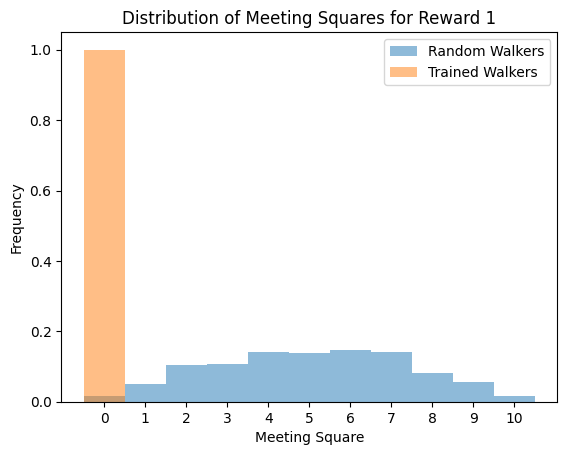

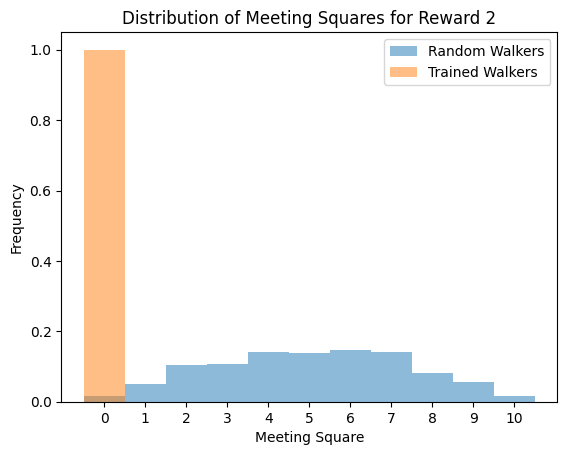

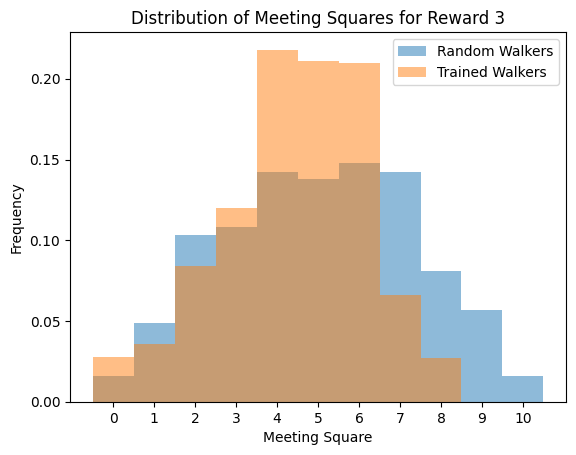

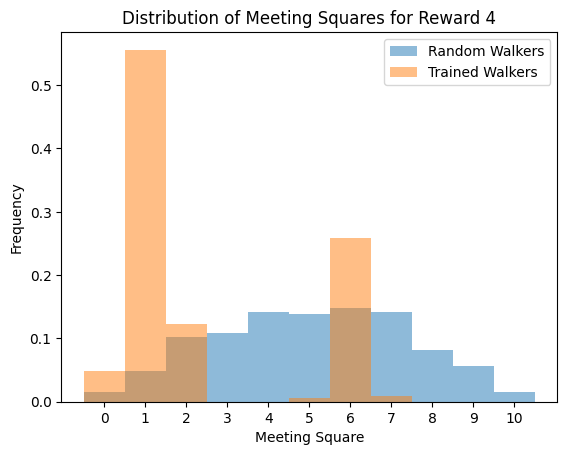

In [ ]:
# Get the meeting squares for random walkers
random_walker_alice = Walker(
    name='Random Alice',
    start_position=START_POS_ALICE,
    world_dimension=NUMBER_OF_SQUARES,
    use_brain=False,
    learn=False
)
random_walker_bob = Walker(
    name='Random Bob',
    start_position=START_POS_BOB,
    world_dimension=NUMBER_OF_SQUARES,
    use_brain=False,
    learn=False
)

_, meeting_squares_random, _, _, _, _ = playgames(
    random_walker_alice, random_walker_bob, NUMBER_OF_SQUARES,
    linear_reward, number_of_games=NUMBER_OF_GAMES
)

# Get the meeting squares for the trained walkers
meeting_results = []
for couple in trained_walkers:
    walker_alice = couple['walker_alice']
    walker_alice.learn = False # Disable learning for the final evaluation
    walker_alice.softmax_temperature = 0.1 # Set a low temperature for exploration
    walker_bob = couple['walker_bob']
    _, meeting_squares, _, _, _, _ = playgames(
        walker_alice, walker_bob, NUMBER_OF_SQUARES, reward_function,
    )
    meeting_results.append(meeting_squares)

# Plot the meeting squares
for i, meeting_squares in enumerate(meeting_results):
    # Plot the meeting squares for random walkers
    plt.hist(meeting_squares_random, bins=np.arange(NUMBER_OF_SQUARES + 1) - 0.5, density=True, alpha=0.5, label='Random Walkers')
    plt.hist(meeting_squares, bins=np.arange(NUMBER_OF_SQUARES + 1) - 0.5, density=True, alpha=0.5, label='Trained Walkers')
    plt.title('Distribution of Meeting Squares for Reward ' + str(i + 1))
    plt.xlabel('Meeting Square')
    plt.ylabel('Frequency')
    plt.xticks(np.arange(NUMBER_OF_SQUARES))
    plt.legend()
    plt.show()

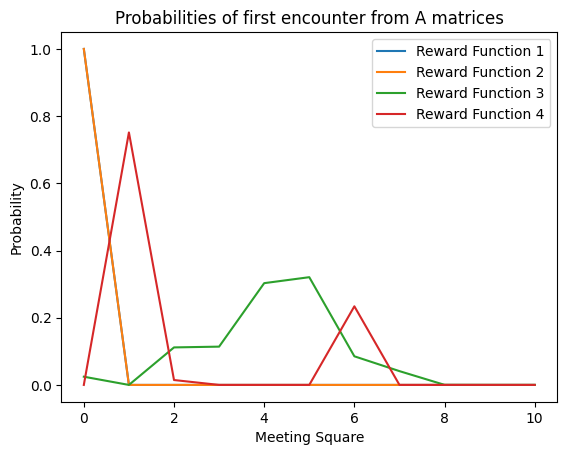

In [ ]:
# Extract the A matrices from the trained walkers
A_matrices = []

for couple in trained_walkers:
    walker_alice = couple['walker_alice']
    walker_bob = couple['walker_bob']
    
    alice_prob_tensor = walker_alice.get_policy_tensor()
    bob_prob_tensor = walker_bob.get_policy_tensor()

    impose_reflective_boundary_conditions(alice_prob_tensor)
    impose_reflective_boundary_conditions(bob_prob_tensor)

    A = build_matrix_A(alice_prob_tensor, bob_prob_tensor)
    add_absorbent_interactions(A, NUMBER_OF_SQUARES)
    A = remove_forbidden_compenetraion_processes(A)
    A_matrices.append(A)

# Specifing the start distribution

P0_Alice = np.zeros(NUMBER_OF_SQUARES)
P0_Alice[START_POS_ALICE] = 1

P0_Bob = np.zeros(NUMBER_OF_SQUARES)
P0_Bob[START_POS_BOB] = 1

# General P0

P0 = np.kron(P0_Alice, P0_Bob)

# Compute the first encounter probability distrubution from the A matrices

for i, A in enumerate(A_matrices):
    eigenvalues, eigenvectors = np.linalg.eig(A)
    M = np.linalg.inv(eigenvectors).T
    M = np.real(M)
    p=[]
    for j in range(NUMBER_OF_SQUARES):
        prob = 0
        for k in range(NUMBER_OF_SQUARES**2):
            prob += P0[k] * M[k, j]
        p.append(prob)

    plt.plot(p, label=f'Reward Function {i + 1}')
plt.title('Probabilities of first encounter from A matrices')
plt.xlabel('Meeting Square')
plt.ylabel('Probability')
plt.legend()
plt.show()

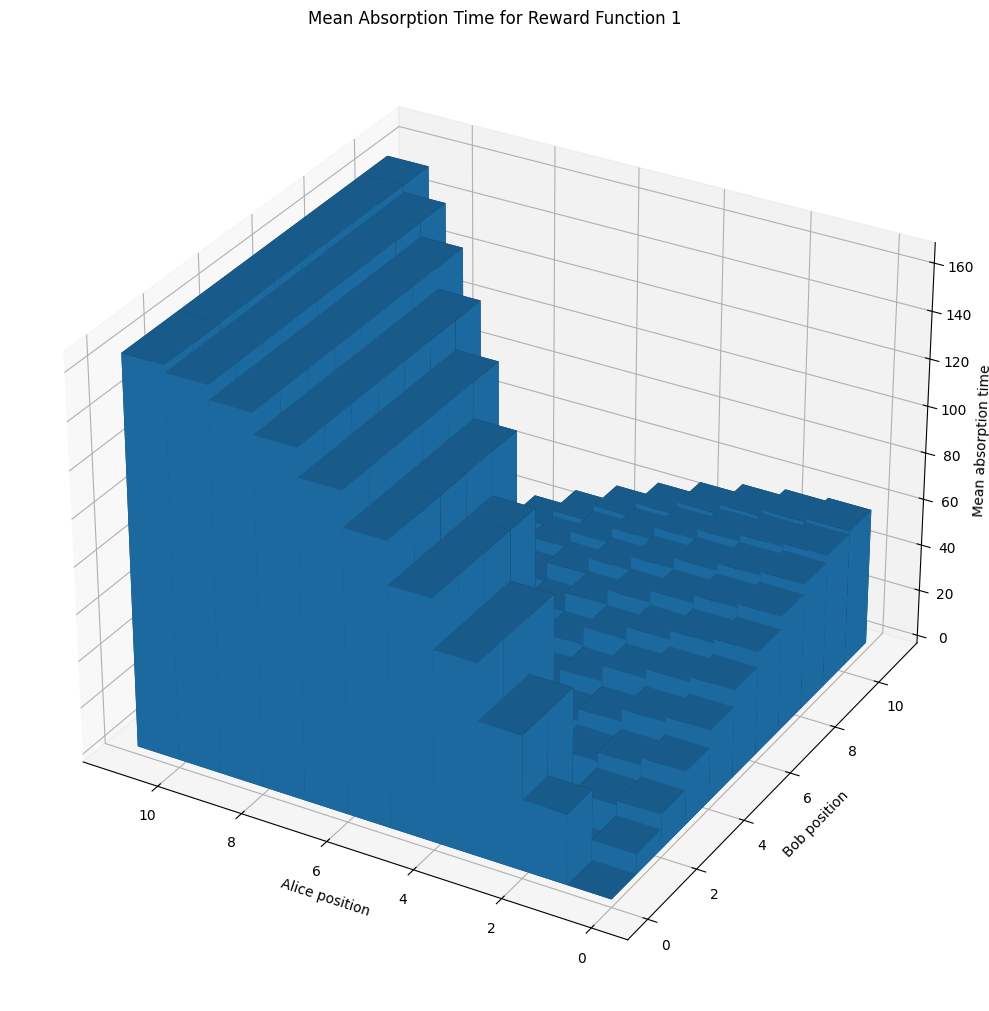

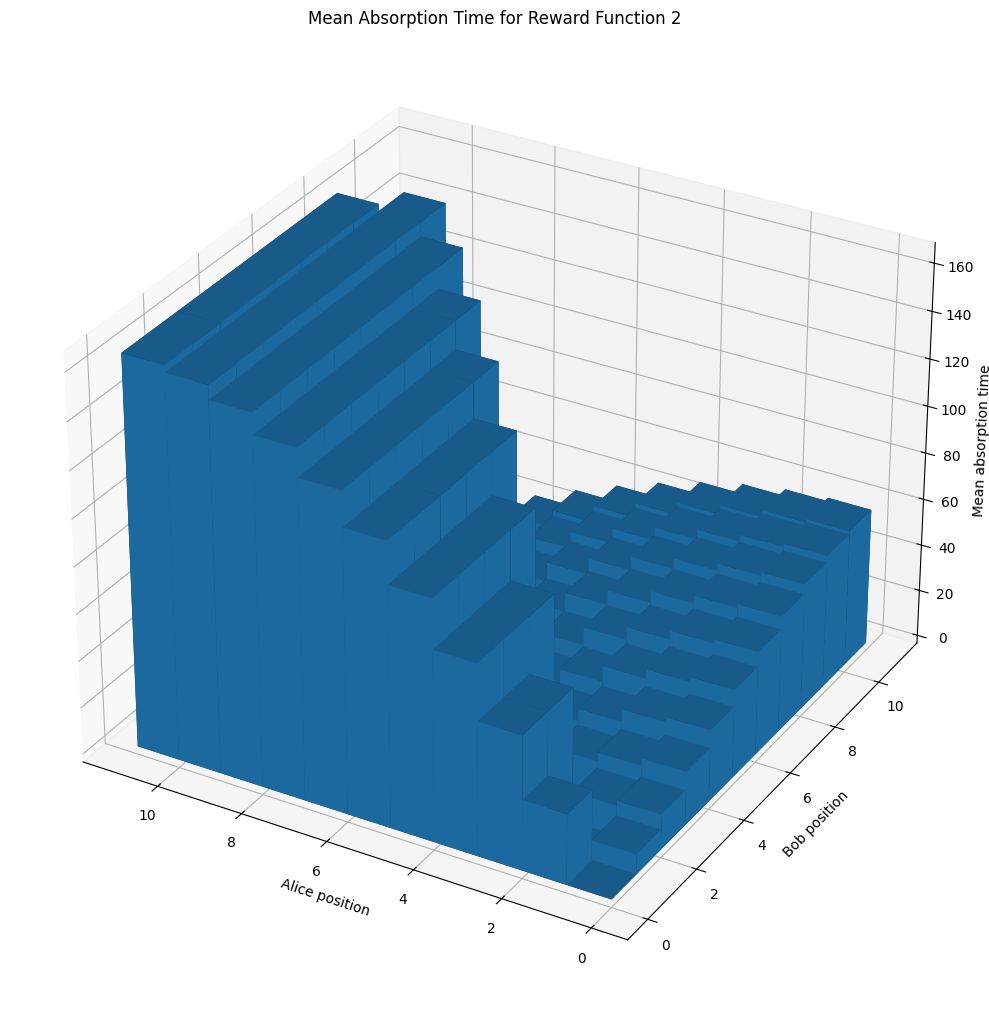

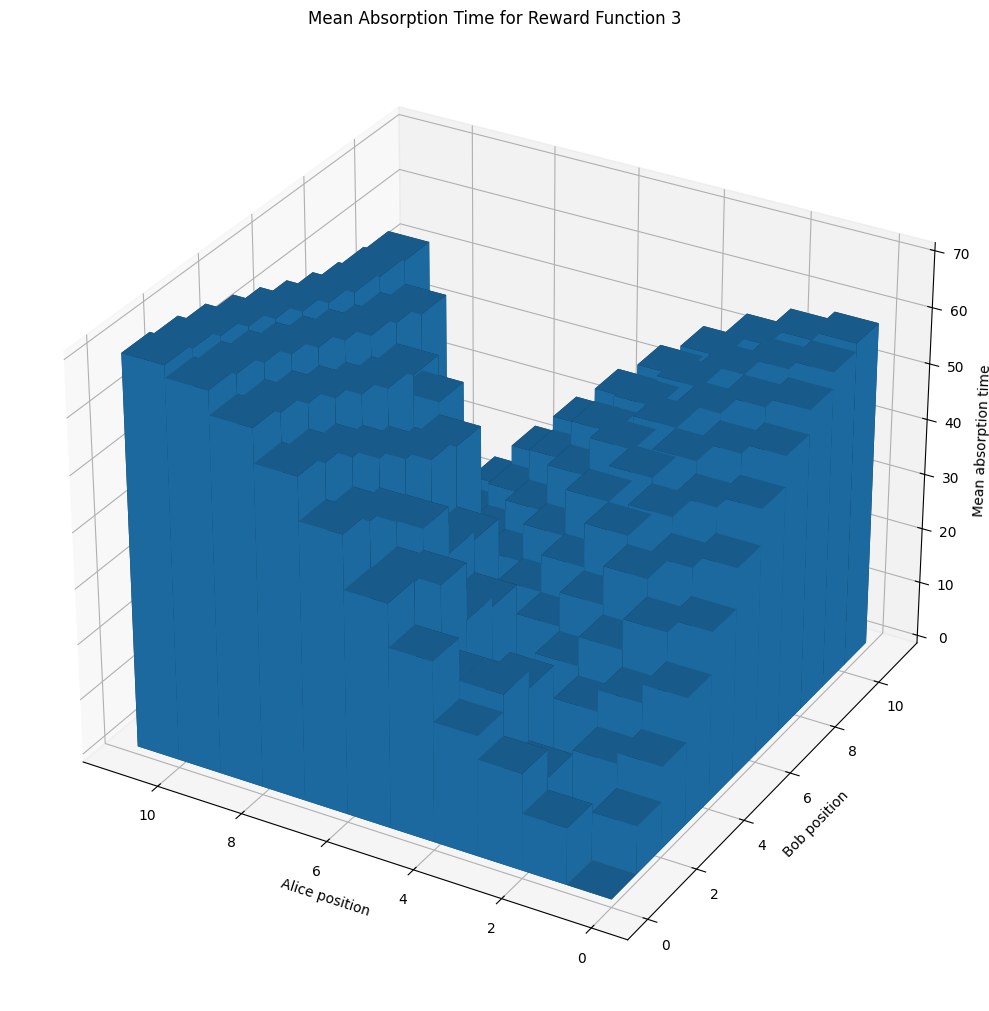

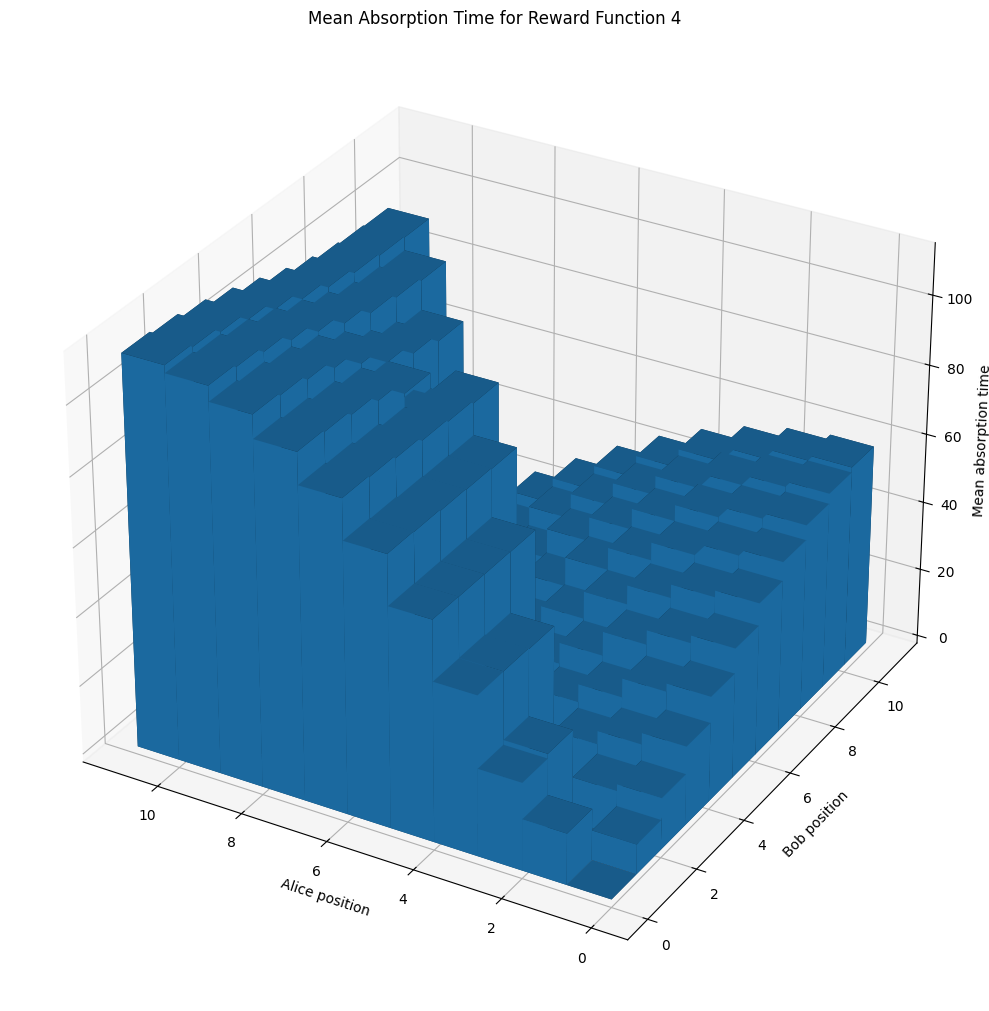

In [ ]:
# Get the times of first encounter for the trained walkers

trap_indices_list = [i + (i-1)*NUMBER_OF_SQUARES - 1 for i in range(1, NUMBER_OF_SQUARES+1)]

time_vectors = []

for i, A in enumerate(A_matrices):
    # Calculate theoretical mean absorbtion time

    A_modded = np.copy(A)

    for index in trap_indices_list:
        A_modded[:, index] = np.zeros(NUMBER_OF_SQUARES**2)

    c_vector = np.ones(NUMBER_OF_SQUARES**2)

    for index in trap_indices_list:
        c_vector[index] = 0

    main_matrix = np.linalg.inv(np.eye(NUMBER_OF_SQUARES**2) - np.transpose(A_modded))

    time_vector =np.matmul(main_matrix, c_vector)

    time_vectors.append(time_vector)

def get_correct_index(a, b):
    return NUMBER_OF_SQUARES* (b) + a

for i, time_vector in enumerate(time_vectors):
    fig = plt.figure(figsize=(12,10), constrained_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title('Mean Absorption Time for Reward Function ' + str(i + 1))
    x = []
    y = []
    z = []
    for a in range(NUMBER_OF_SQUARES):
        for b in range(NUMBER_OF_SQUARES):
            index = get_correct_index(a, b)
            x.append(a)
            y.append(b)
            z.append(time_vector[index])
    ax.bar3d(x, y, np.zeros_like(z), 1, 1, z, shade=True)
    ax.invert_xaxis()
    ax.set_xlabel('Alice position')
    ax.set_ylabel('Bob position')
    ax.set_zlabel('Mean absorption time')
    # Adjust the border to not cut the axis labels
    plt.show()